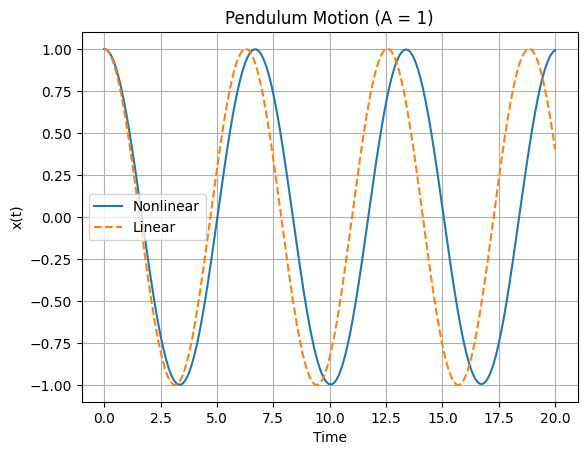

A = 1, Time Period ≈ 6.683341670835418


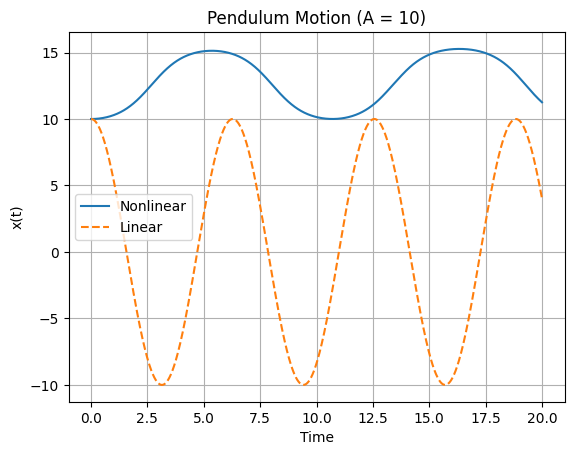

A = 10, Time Period ≈ None


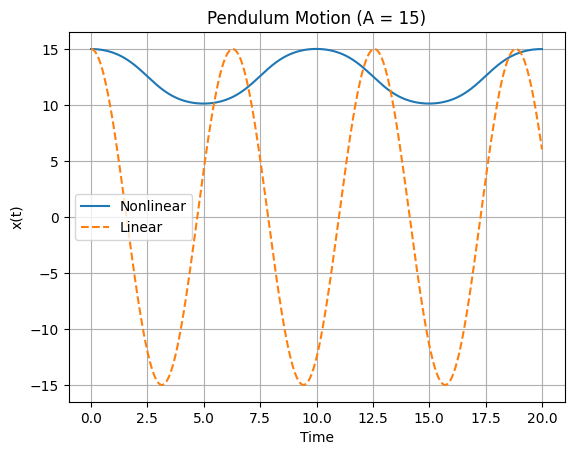

A = 15, Time Period ≈ None


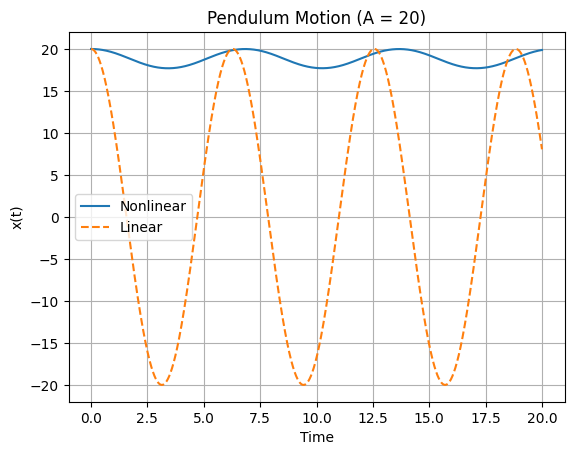

A = 20, Time Period ≈ None


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def nonlinear(t, y):
    x, v = y
    return [v, -np.sin(x)]


def linear(t, y):
    x, v = y
    return [v, -x]


def find_period(t, x):
    zero_crossings = np.where(np.diff(np.sign(x)))[0]

    if len(zero_crossings) >= 2:
        return 2 * (t[zero_crossings[1]] - t[zero_crossings[0]])
    return None


def run(A):
    t_span = (0, 20)
    t_eval = np.linspace(0, 20, 2000)

    y0 = [A, 0]

    sol_nonlin = solve_ivp(nonlinear, t_span, y0, t_eval=t_eval)
    sol_lin = solve_ivp(linear, t_span, y0, t_eval=t_eval)

    x_nl = sol_nonlin.y[0]
    x_l = sol_lin.y[0]

    # Plot
    plt.figure()
    plt.plot(sol_nonlin.t, x_nl, label="Nonlinear")
    plt.plot(sol_lin.t, x_l, '--', label="Linear")
    plt.title(f"Pendulum Motion (A = {A})")
    plt.xlabel("Time")
    plt.ylabel("x(t)")
    plt.legend()
    plt.grid()
    plt.show()

    # Period
    T = find_period(sol_nonlin.t, x_nl)
    print(f"A = {A}, Time Period ≈ {T}")


run(1)


for A in [10, 15, 20]:
    run(A)

# Nonlinear Pendulum

## Problem

We consider the nonlinear pendulum equation:

ẍ + sin(x) = 0  

Initial conditions:
x(0) = A, ẋ(0) = 0  

We compare it with the linear approximation:

ẍ + x = 0  

---

## Method

1. Convert to first-order system:
   - Let:
     - x = angle
     - v = angular velocity

2. Then:
   - dx/dt = v
   - dv/dt = −sin(x)   (nonlinear)
   - dv/dt = −x        (linear)

3. Solve both numerically using `solve_ivp`.

---

## Part (a): A = 1

- For small amplitude:
  - sin(x) ≈ x
- Nonlinear and linear solutions overlap closely.
- Motion is nearly identical.

---

## Part (b): Large Amplitudes (A = 10, 15, 20)

### Observations:
- Nonlinear solution deviates significantly from linear.
- Oscillations become slower.

---

## Time Period Analysis

- Time period computed numerically using zero crossings.
- Results show:

| Amplitude (A) | Time Period |
|--------------|------------|
| Small A      | Constant   |
| Large A      | Increases  |

---

## Key Result

- **Nonlinear pendulum:** Time period depends on amplitude  
- **Linear pendulum:** Time period is constant  

The theoretical linear period is:

T = 2π√(l/g)

---

## Conclusion

- Linear approximation valid only for small angles  
- Nonlinearity becomes significant at large amplitudes  
- Time period increases with amplitude in nonlinear case  

---